# Method Verification

In this script, the probabilities from the MCWF method is compared against the probabilities from a density matrix simulation to validate the MCWF method as a valid implementation for noisy statevector simulations.

## Import Libraries

In [1]:
from NoisyCircuits import QuantumCircuit as QC
from NoisyCircuits.utils.CreateNoiseModel import GetNoiseModel, CreateNoiseModel
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import json

## Initialize the Noise Model

In [2]:
api_json = json.load(open(os.path.join(os.path.expanduser("~"), "ibm_api.json"), "r"))
token = api_json["apikey"] # Replace with your Token
service_crn = api_json["service-crn"] # Replace with your Service CRN
backend_name = "ibm_fez"
qpu_type = "heron"
verbose = False

Run the code below to use the latest noise model from IBM hardware calibration data. This requires a valid IBM Quantum Token as well as a service-crn for available quantum backend instances. If a valid token is not available, then skip the below cell and execute the next cell to use the sample noise data.

In [3]:
noise_model = GetNoiseModel(
    backend_name=backend_name,
    token=token,
    service_crn=service_crn,
).get_noise_model()

Run the code below in case API access is not feasible, and use the sample noise model provided with the software

In [ ]:
if qpu_type == "eagle":
    file_path = "https://raw.githubusercontent.com/Sats2/NoisyCircuits/main/noise_models/Noise_Model_Eagle_QPU.pkl"
    noise_model = pickle.load(open(file_path, "rb"))
elif qpu_type == "heron":
    file_path = "https://raw.githubusercontent.com/Sats2/NoisyCircuits/main/noise_models/Sample_Noise_Model_Heron_QPU.csv"
    noise_model = CreateNoiseModel(calibration_data_file=file_path, 
                                   basis_gates=[["x", "sx", "rz", "rx"], ["cz", "rzz"]]).create_noise_model()
else:
    raise ValueError("Invalid qpu_type. Choose either 'heron' or 'eagle'.")

## Define the Randomized Circuit

Define the function that can generate a randomized circuit that can be executed using density matrix simulation and as an MCWF execution.

In [10]:
def build_random_circuit(circuit, depth, num_qubits):
    circuit.refresh()
    if qpu_type == "eagle":
        gate = {
            "X" : circuit.X,
            "SX": circuit.SX,
        }
        two_qubit_gate = circuit.ECR
    elif qpu_type == "heron":
        gate = {
            "X" : lambda q: circuit.X(q),
            "SX": lambda q: circuit.SX(q),
            "RX": lambda q: circuit.RX(np.random.uniform(-2*np.pi, 2*np.pi), q)
        }
        two_qubit_gate = circuit.CZ
    else:
        raise ValueError("Unsupported QPU type. Supported types are 'heron' and 'eagle'.")
    for _ in range(depth):
        for i in range(num_qubits):
            choice = np.random.choice(list(gate.keys()))
            gate[choice](i)
        for i in range(num_qubits-1):
            two_qubit_gate(i, i+1)

## Define the Metrics

Define the function that can compute the desired validation metrics between the reference probability distribution (from the density matrix) and the probability distribution from the MCWF method. The chosen metrics are:

1. **Battacharyya Coefficient:** Defines the overlap between two probability distributions and is bounded between $[0,1]$, where a value of $1$ indicates a similar distributions. The value for two discrete distributions can be computed using the equation below.
\begin{equation*}
BC(p,q) = \sum_{i=1}^{N} \sqrt{p_iq_i}
\end{equation*}
Interpretation: The closer the two distributions are in similarity, the closer value of the Battacharyya Coefficient is to $1$.

2. **Battacharyya Distance:** Provides a distance measure that indicates the dissimilarity between two probability distributions and lies between $[0, \infty]$, where a value of $0$ indicates a similar distribution and higher the value, the greater the dissimilarity between the two distributions. The value for two discrete distributions can be computed using the equation below.
\begin{equation*}
BD(p,q) = -\text{log}(BC(p,q))
\end{equation*}

3. **Hellinger Distance:** Provides a measure of the geometric difference between two probability distributions and is bounded between $[0,1]$, where a value of $0$ indicates a similar distribution. The value for two discrete distributions can be computed using the equation below.
\begin{equation*}
HD(p,q) = \frac{1}{\sqrt{2}} \sqrt{\sum_{i=1}^{N}(\sqrt{p_i} - \sqrt{q_i})^2}
\end{equation*}

4. **Jenson-Shannon (JS) Divergence:** It is the smoothed, symmetric version of the KL divergence, measuring the average information divergence between the two distributions and is bounded between $[0, \text{log}(2)]$ where lower the value the lesser the information loss. The value for two discrete distributions can be computed using the equation below.
\begin{equation*}
JSD(p||q) = \frac{1}{2}(KL(p||m) + KL(q||m)) \text{ with } m = \frac{p+q}{2}
\end{equation*}

\begin{equation*}
KL(a||b) = \sum_{i=1}^{N}a_i\text{log}(\frac{a_i}{b_i})
\end{equation*}

In [5]:
def compute_metrics(pd_1, pd_2):
    battacharyya_coefficient = np.sum(np.sqrt(pd_1 * pd_2))
    battacharyya_distance = -np.log(battacharyya_coefficient)
    hellinger_distance = np.sqrt(np.sum((np.sqrt(pd_1) - np.sqrt(pd_2))**2)) / np.sqrt(2)
    m = 0.5 * (pd_1 + pd_2)
    js = 0.5 * np.sum(pd_1 * np.log(1e-10 + pd_1 / m) + pd_2 * np.log(1e-10 + pd_2 / m))
    return (battacharyya_coefficient, battacharyya_distance, hellinger_distance, js)

## Define Randomized Test Parameters

Define the range for the number of qubits to use and the total number of single qubit gates per qubit. Note that an entanglement gate is applied to after each single qubit gate (recommended to start with 2 qubits).

In [6]:
qubit_list = [2, 3, 4, 5, 6, 7]
depth_list = [5, 20, 50, 100]

In [7]:
metrics_identifier = ("Battacharyya Coefficient", "Battacharyya Distance", "Hellinger Distance", "Jensen-Shannon Divergence")

def plot_metrics(dict_list, trajectory_list):
    depths = depth_list
    qubits = qubit_list
    
    for depth in depths:
        fig, ax = plt.subplots(2, 2, figsize=(12, 8))
        for i, metric in enumerate(metrics_identifier):
            for traj_idx, traj_count in enumerate(trajectory_list):
                metric_values = []
                for num_qubits in qubits:
                    key = (num_qubits, depth)
                    if key in dict_list[traj_idx]:
                        metric_values.append(dict_list[traj_idx][key][metric])
                    else:
                        metric_values.append(0)
                ax[i//2, i%2].plot(qubits, metric_values, label=f"Trajectories: {traj_count}", marker='o')
            
            ax[i//2, i%2].set_title(f"{metric}")
            ax[i//2, i%2].set_xlabel("Number of Qubits")
            ax[i//2, i%2].set_xticks(qubits)
            ax[i//2, i%2].set_ylabel(metric)
            ax[i//2, i%2].legend()
            ax[i//2, i%2].grid()
        plt.suptitle(f"Comparison for Depth={depth}", fontsize=16)   
        plt.tight_layout()
        plt.show()

In [8]:
def run_experiment(sim_backend):
    mcwf_10t_results = {}
    mcwf_100t_results = {}
    mcwf_200t_results = {}
    mcwf_500t_results = {}
    mcwf_1000t_results = {}
    log = open("Results_Log_File_{}.log".format(sim_backend), "w")
    for num_qubits in qubit_list:
        circ = QC(num_qubits=num_qubits, 
                noise_model=noise_model,
                backend_qpu_type=qpu_type, 
                num_trajectories=1, 
                sim_backend = sim_backend,
                num_cores=50, 
                threshold=1e-8, 
                jsonize=True,
                verbose=verbose)
        for depth in depth_list:
            circ.refresh()
            log.write("===========================================================================\n")
            log.write(f"Running Circuit with {num_qubits} qubits and depth {depth}\n")
            build_random_circuit(circ, depth, num_qubits)
            probs_density_matrix = circ.run_with_density_matrix(list(range(num_qubits)))
            probs_mcwf_10t = circ.execute(list(range(num_qubits)), num_trajectories=10)
            probs_mcwf_100t = circ.execute(list(range(num_qubits)), num_trajectories=100)
            probs_mcwf_200t = circ.execute(list(range(num_qubits)), num_trajectories=200)
            probs_mcwf_500t = circ.execute(list(range(num_qubits)), num_trajectories=500)
            probs_mcwf_1000t = circ.execute(list(range(num_qubits)), num_trajectories=1000)
            metrics_10t = compute_metrics(probs_density_matrix, probs_mcwf_10t)
            metrics_100t = compute_metrics(probs_density_matrix, probs_mcwf_100t)
            metrics_200t = compute_metrics(probs_density_matrix, probs_mcwf_200t)
            metrics_500t = compute_metrics(probs_density_matrix, probs_mcwf_500t)
            metrics_1000t = compute_metrics(probs_density_matrix, probs_mcwf_1000t)
            key = (num_qubits, depth)
            mcwf_10t_results[key] = dict(
                [("num_qubits", num_qubits), ("depth", depth)] +
                [(metric, metrics_10t[i]) for i, metric in enumerate(metrics_identifier)]
            )
            mcwf_100t_results[key] = dict(
                [("num_qubits", num_qubits), ("depth", depth)] +
                [(metric, metrics_100t[i]) for i, metric in enumerate(metrics_identifier)]
            )
            mcwf_200t_results[key] = dict(
                [("num_qubits", num_qubits), ("depth", depth)] +
                [(metric, metrics_200t[i]) for i, metric in enumerate(metrics_identifier)]
            )
            mcwf_500t_results[key] = dict(
                [("num_qubits", num_qubits), ("depth", depth)] +
                [(metric, metrics_500t[i]) for i, metric in enumerate(metrics_identifier)]
            )
            mcwf_1000t_results[key] = dict(
                [("num_qubits", num_qubits), ("depth", depth)] +
                [(metric, metrics_1000t[i]) for i, metric in enumerate(metrics_identifier)]
            )
            log.write(f"Metrics for MCWF with {10} Trajectories:\n")
            for i in range(len(metrics_identifier)):
                log.write(f"{metrics_identifier[i]}: {metrics_10t[i]}\n")
            log.write(f"Metrics for MCWF with {100} Trajectories:\n")
            for i in range(len(metrics_identifier)):
                log.write(f"{metrics_identifier[i]}: {metrics_100t[i]}\n")
            log.write(f"Metrics for MCWF with {200} Trajectories:\n")
            for i in range(len(metrics_identifier)):
                log.write(f"{metrics_identifier[i]}: {metrics_200t[i]}\n")
            log.write(f"Metrics for MCWF with {500} Trajectories:\n")
            for i in range(len(metrics_identifier)):
                log.write(f"{metrics_identifier[i]}: {metrics_500t[i]}\n")
            log.write(f"Metrics for MCWF with {1000} Trajectories:\n")
            for i in range(len(metrics_identifier)):
                log.write(f"{metrics_identifier[i]}: {metrics_1000t[i]}\n")
            log.write("===========================================================================\n\n")
            log.flush()
        circ.shutdown()
    return mcwf_10t_results, mcwf_100t_results, mcwf_200t_results, mcwf_500t_results, mcwf_1000t_results

## Perform the Verification with the Randomized Circuits for Various Backends

### Backend - Qiskit

Successfully switched backend to qiskit.


2026-03-06 16:56:33,224	INFO worker.py:1839 -- Calling ray.init() again after it has already been called.


Successfully switched backend to qiskit.


2026-03-06 16:58:23,340	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 16:58:53,928 E 432690 442614] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qiskit.


...

2026-03-06 17:06:21,806	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:06:52,420 E 432690 451697] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qiskit.


2026-03-06 17:12:08,447	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:12:39,117 E 432690 456759] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qiskit.


2026-03-06 17:19:14,098	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:19:44,751 E 432690 462646] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


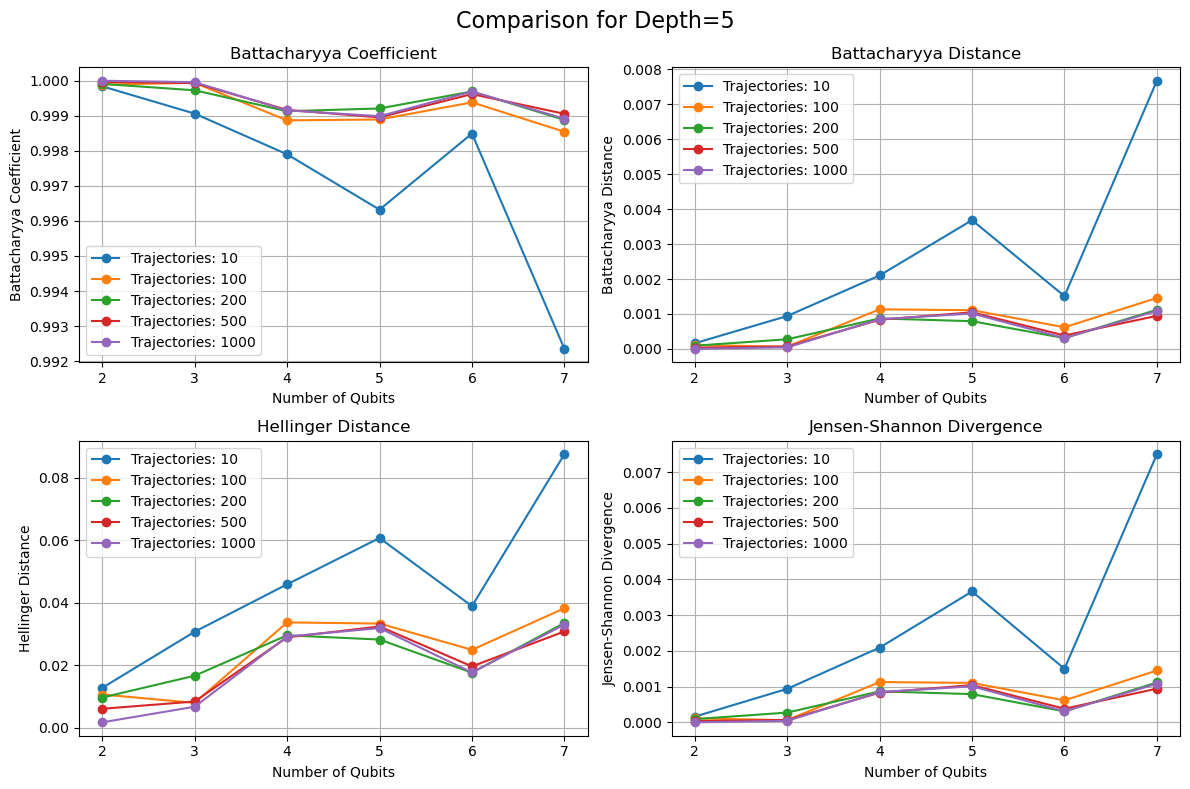

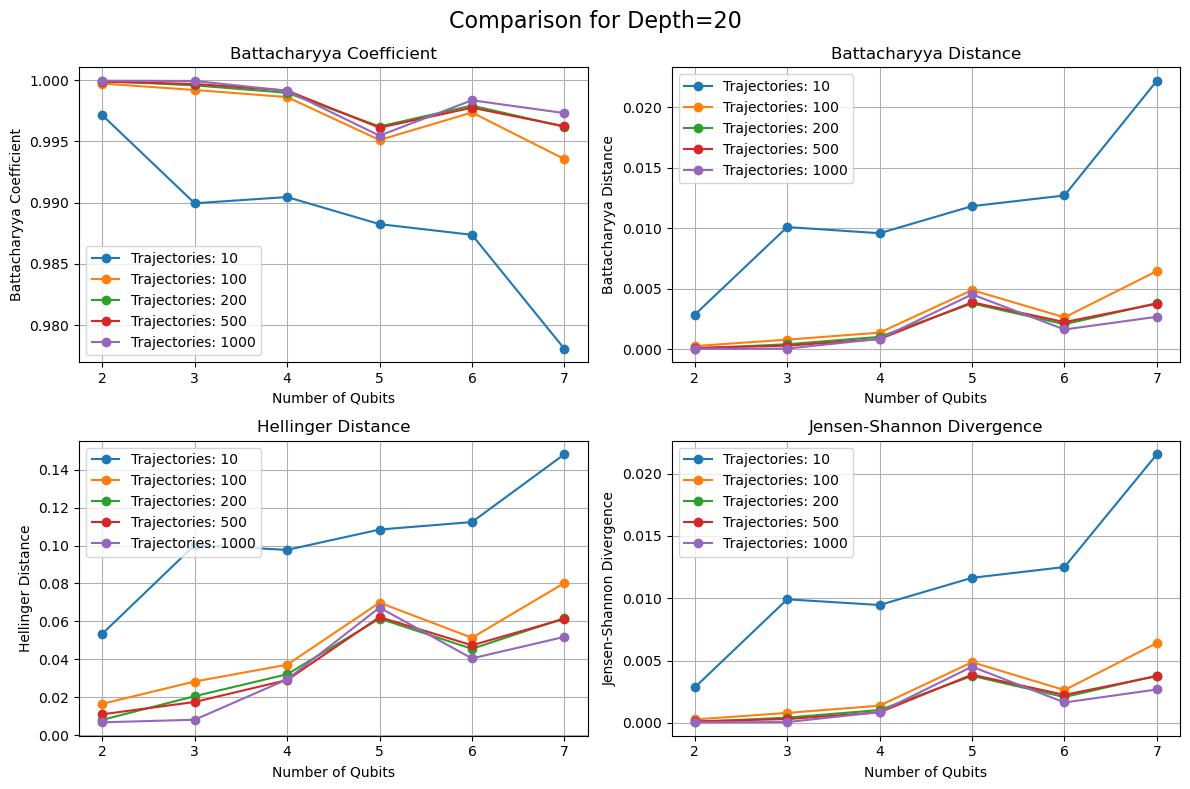

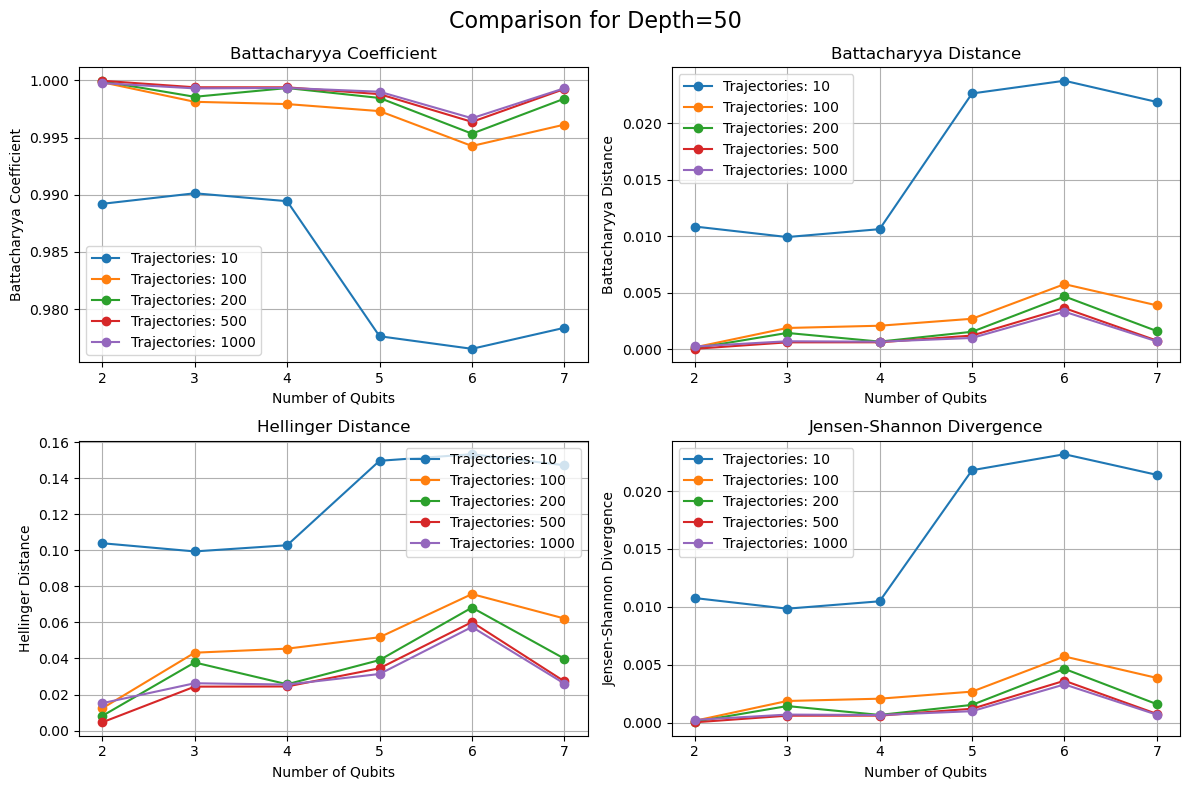

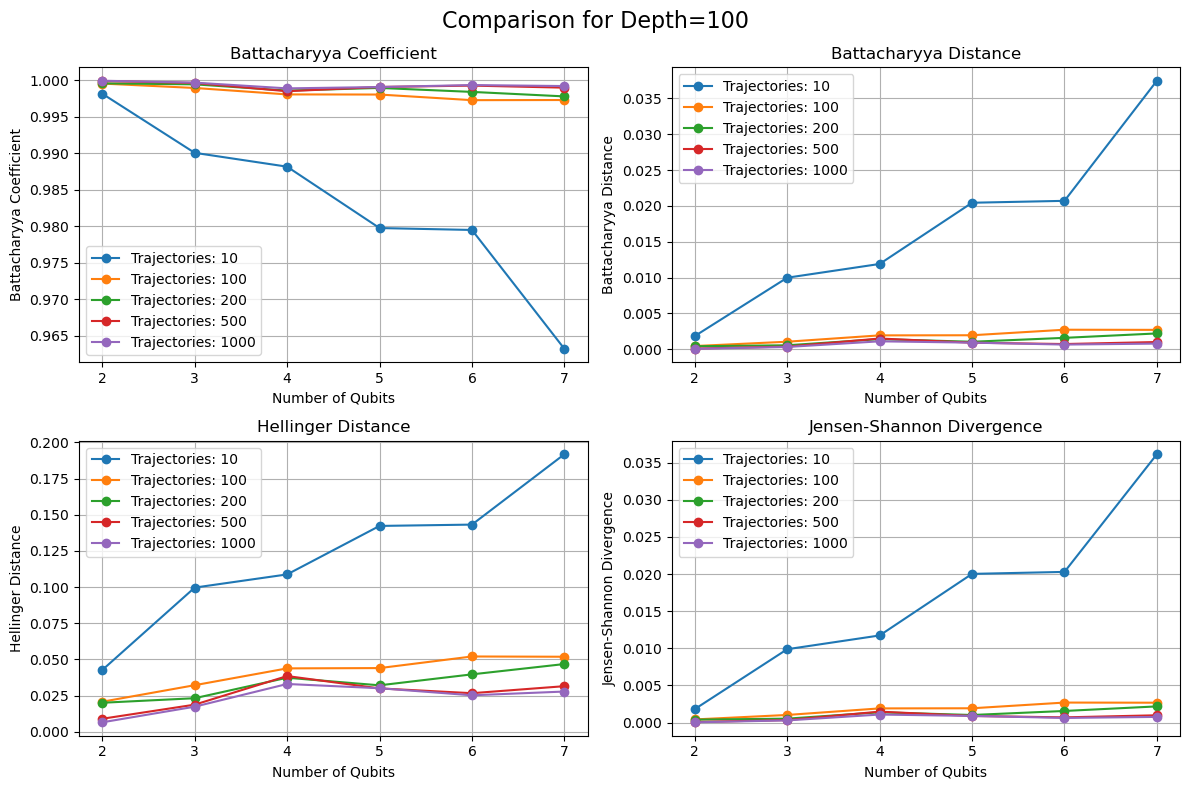

In [11]:
experiment_output = run_experiment(sim_backend="qiskit")
plot_metrics(list(experiment_output), [10, 100, 200, 500, 1000])

### Backend - Pennylane

Successfully switched backend to pennylane.


2026-03-06 17:27:33,293	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:28:03,938 E 432690 468698] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to pennylane.


2026-03-06 17:29:12,546	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:29:43,135 E 432690 472499] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to pennylane.


...

2026-03-06 17:36:09,095	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:36:39,703 E 432690 483081] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to pennylane.


2026-03-06 17:41:01,581	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:41:32,127 E 432690 488803] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to pennylane.


2026-03-06 17:47:31,621	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:48:02,231 E 432690 494661] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


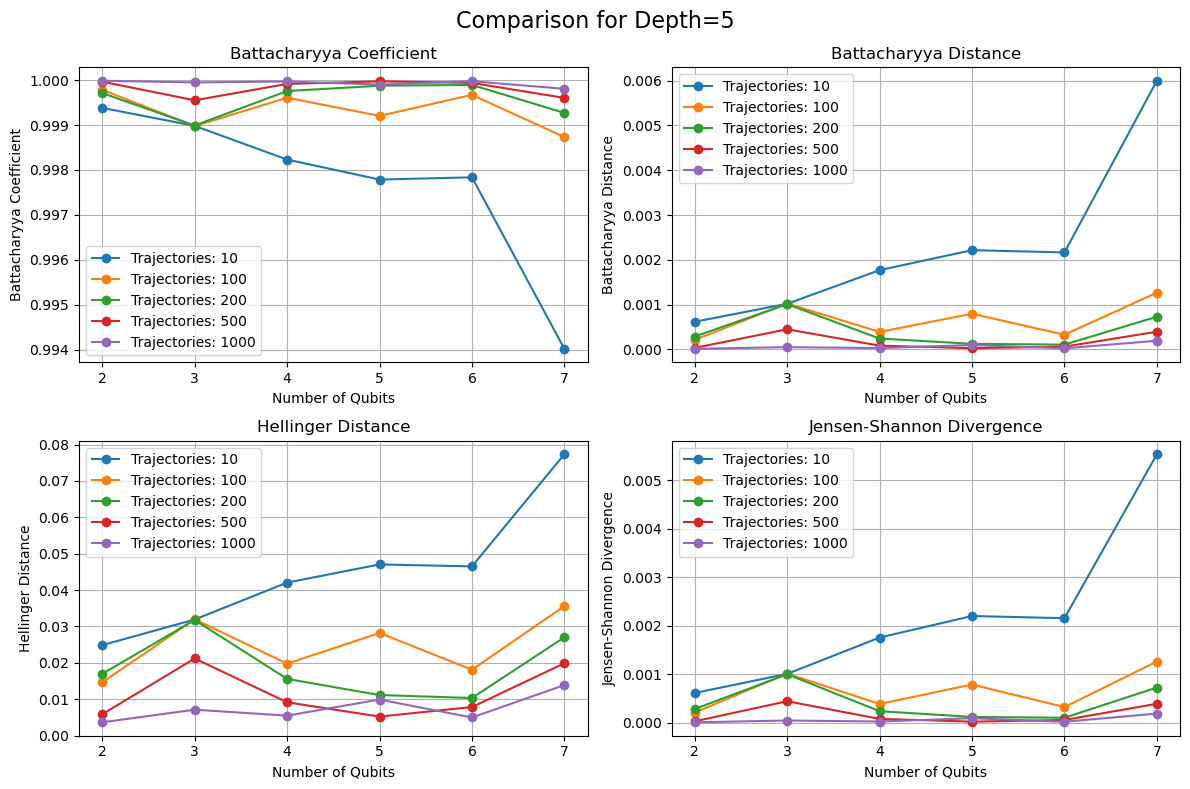

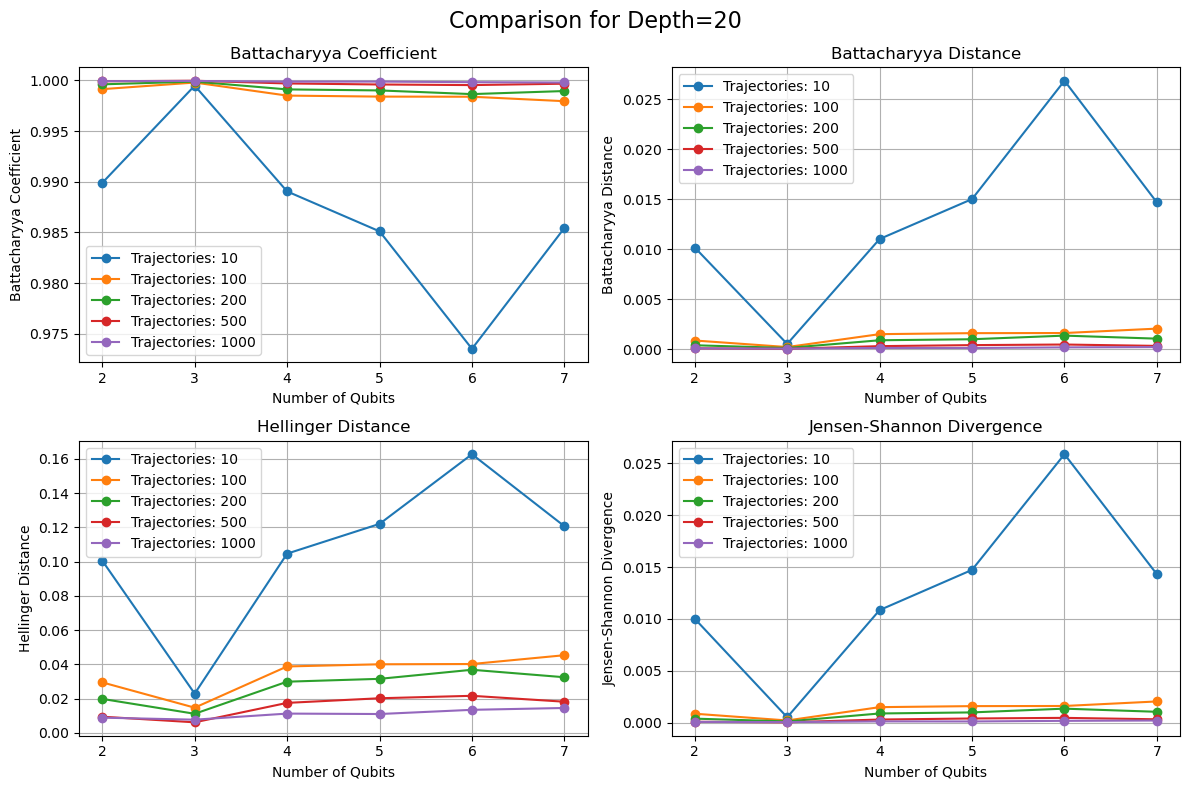

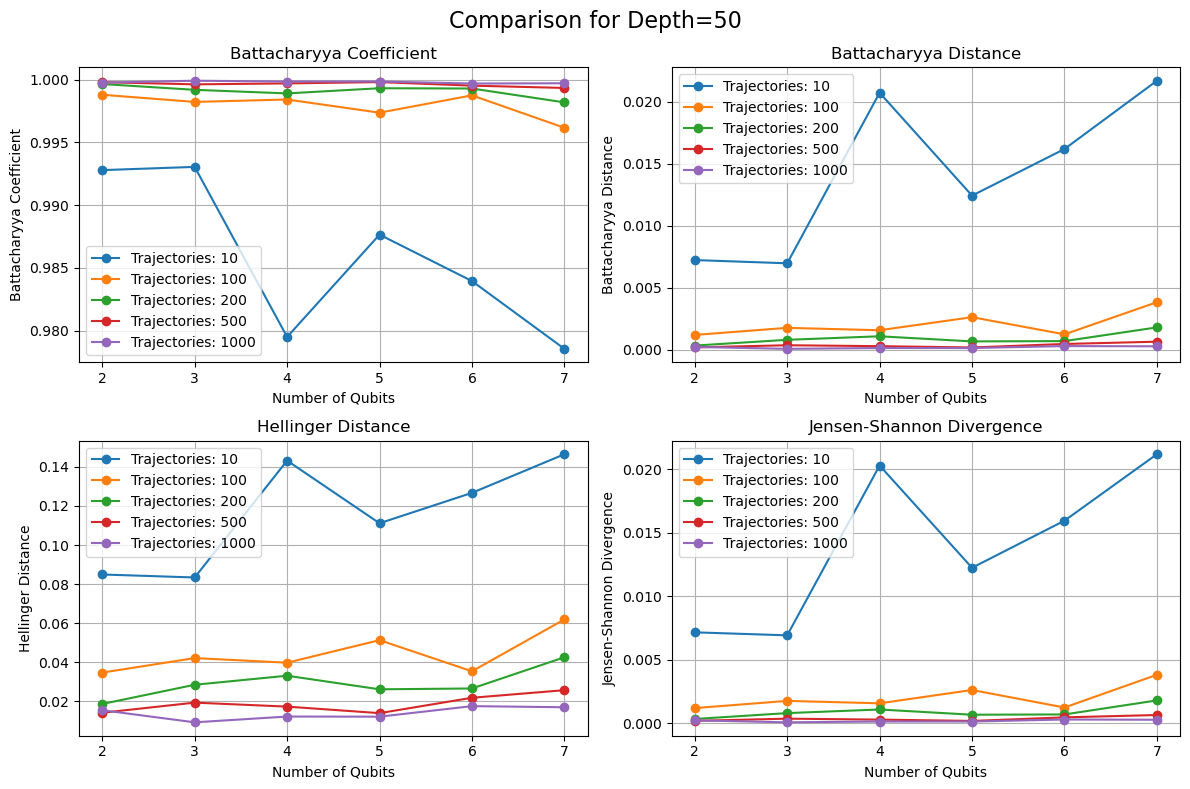

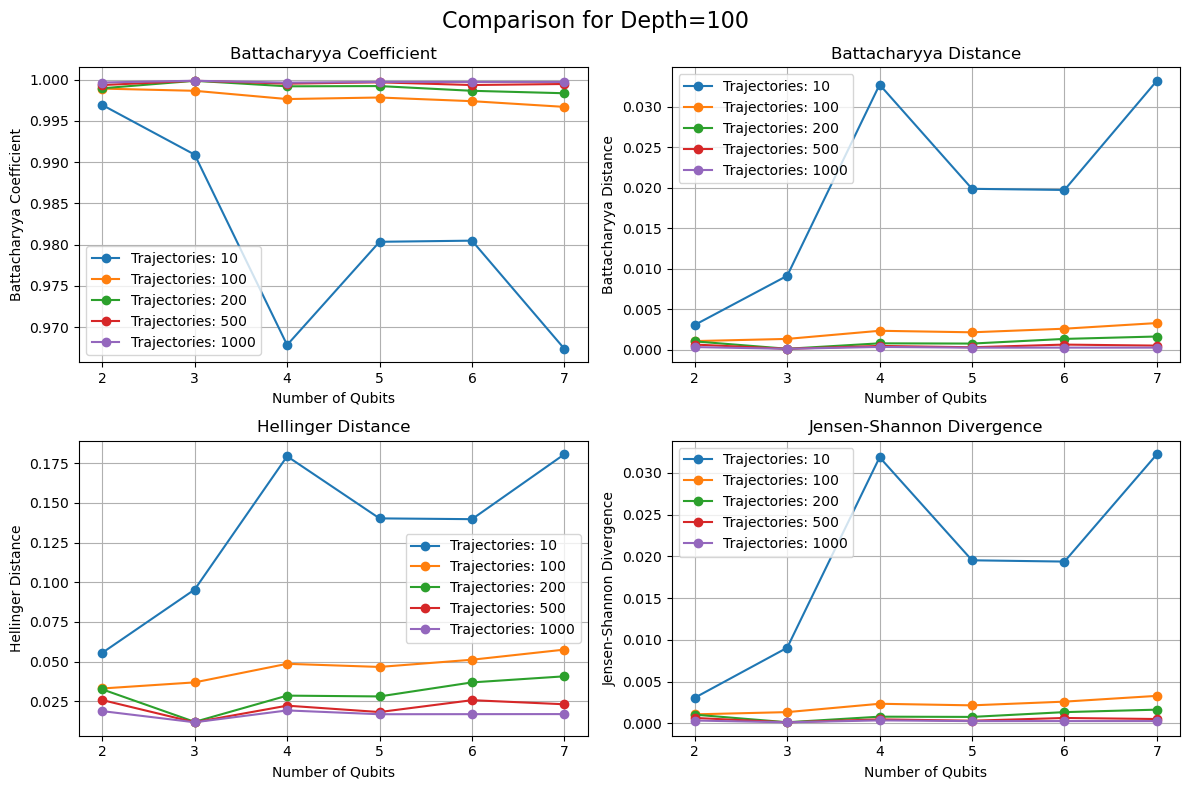

In [12]:
experiment_output = run_experiment(sim_backend="pennylane")
plot_metrics(list(experiment_output), [10, 100, 200, 500, 1000])

### Backend - Qulacs

Successfully switched backend to qulacs.


2026-03-06 17:58:57,557	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 17:59:28,146 E 432690 501178] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qulacs.


2026-03-06 18:00:04,474	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 18:00:35,069 E 432690 504663] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qulacs.


...

2026-03-06 18:04:48,903	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 18:05:19,491 E 432690 511812] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qulacs.


2026-03-06 18:07:48,040	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 18:08:18,648 E 432690 515394] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Successfully switched backend to qulacs.


2026-03-06 18:11:32,971	INFO worker.py:2007 -- Started a local Ray instance.
[2026-03-06 18:12:03,581 E 432690 519011] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


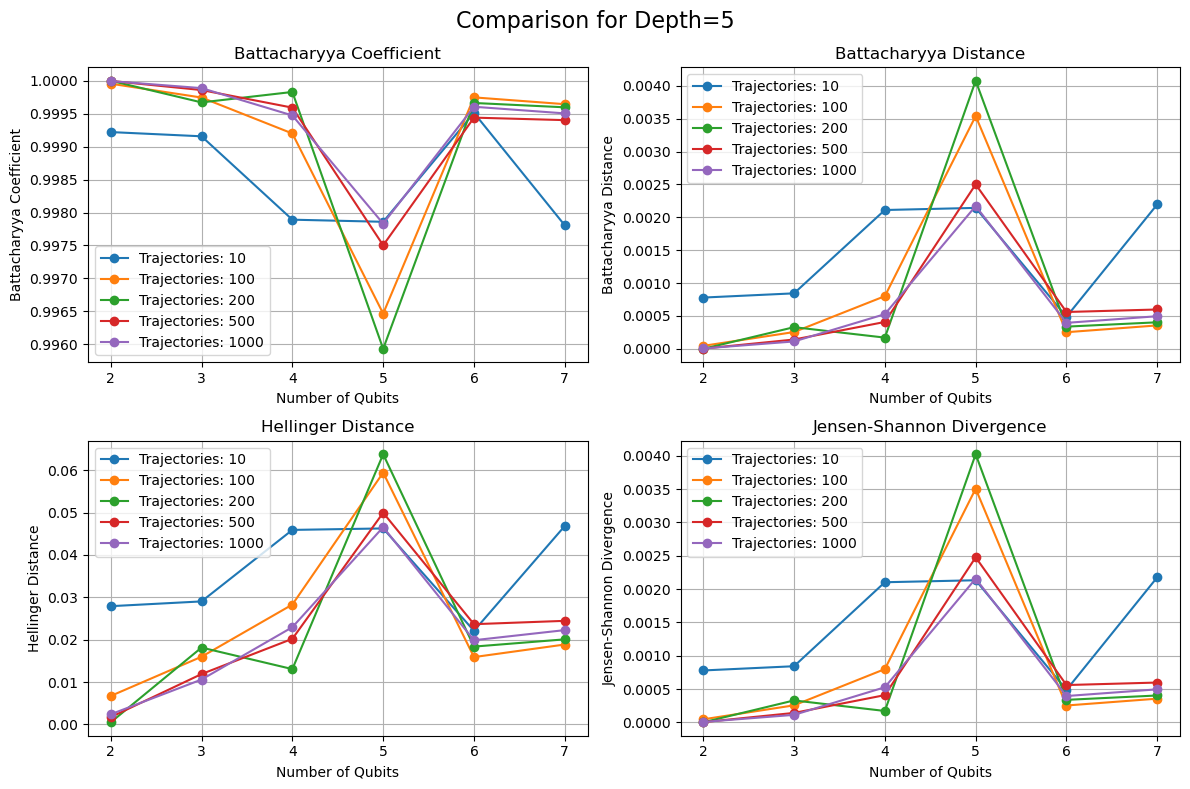

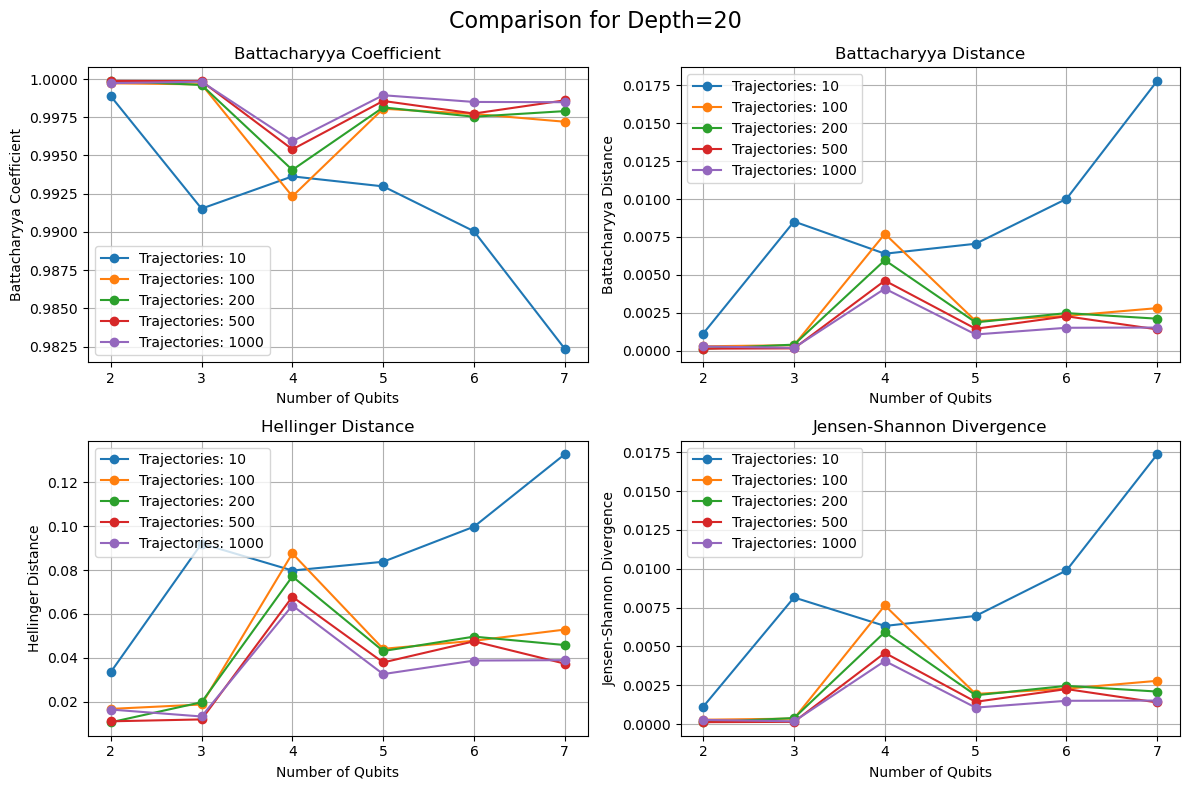

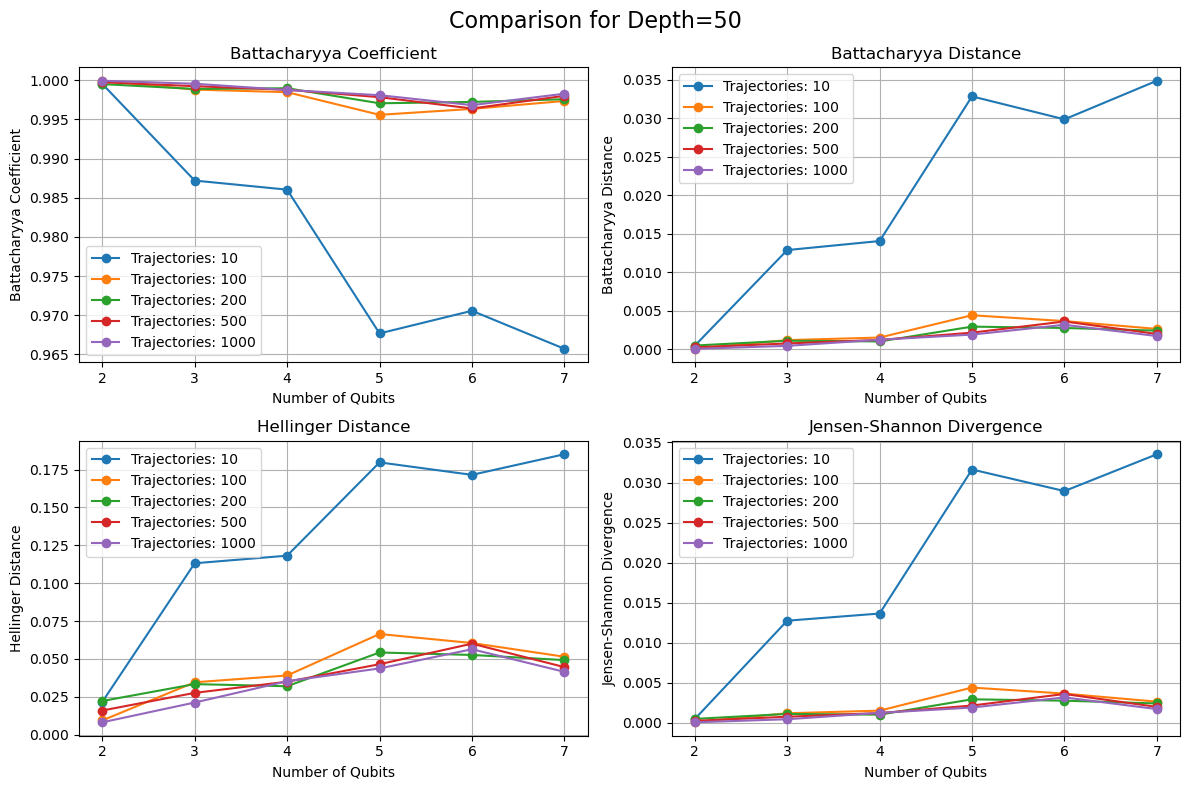

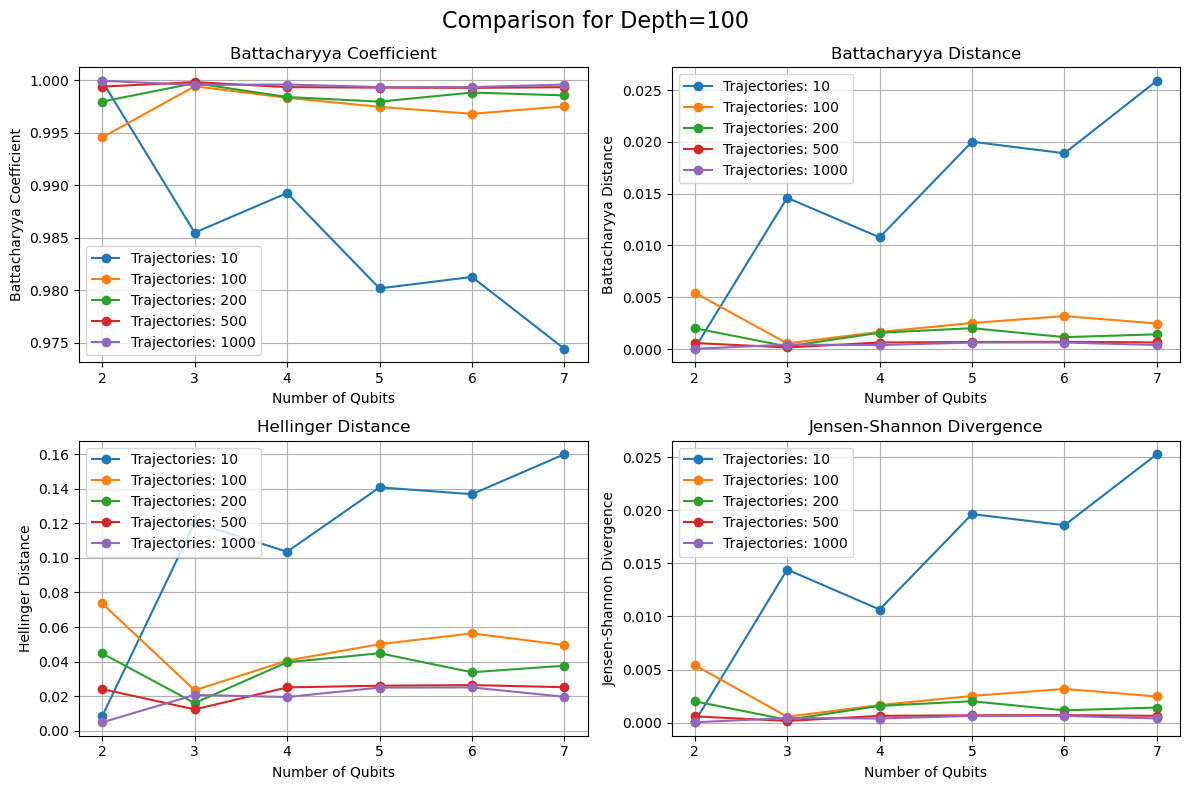

In [13]:
experiment_output = run_experiment(sim_backend="qulacs")
plot_metrics(list(experiment_output), [10, 100, 200, 500, 1000])